# 📘 Track B — Notebook 3: HiFi-GAN Decoding & Full Pipeline Evaluation

**Project:** Synthetic Data Generation for Speech Emotion Recognition  
**Author:** *(your name)*  
**Prerequisites:** Notebook 1 and Notebook 2 must be completed.

---

## What This Notebook Does

1. ✅ GPU health check and memory profiling
2. 🎛️ Converts synthetic HuBERT embeddings → Mel spectrograms via a learned projection
3. 🔊 Decodes Mel spectrograms → `.wav` files using **HiFi-GAN** (pretrained neural vocoder)
4. 🧪 **Early audio sample check** — listen to 5 synthetic samples before running the full decode
5. 📊 Full evaluation suite:
   - Mel spectrogram similarity (MSE, cosine)
   - Emotion classifier trained on real data, tested on synthetic data
   - Accuracy, Precision, Recall, F1 (per-class and macro)
   - Confusion matrix
   - MOS-proxy metric (UTMOS or pseudo-MOS)
6. 💾 Saves all synthetic `.wav` files in the same directory structure as your real dataset

---

## Architecture Overview

```
Synthetic HuBERT Embedding (1536-d)
           ↓
   Linear Projection Layer       ← learns mapping: embedding → mel space
   (1536 → n_mels * n_frames)    ← trained using real (embedding, mel) pairs
           ↓
   Mel Spectrogram (80 × T)
           ↓
   HiFi-GAN Vocoder (pretrained)
           ↓
   Synthetic WAV file
```

**Why a linear projection?** HuBERT embeddings are not directly in mel space.
We train a simple regression model mapping real HuBERT embeddings to their corresponding mel spectrograms.
Then we apply the same projection to synthetic embeddings.

---

## Output
- `synthetic_audio/` — organized as `{actor}/{sessionSYNTH}/{emotion}/{filename}.wav`
- `outputs/evaluation_report.csv` — per-file metrics
- `outputs/confusion_matrix.png`
- `outputs/metrics_summary.png`

---
## 🔧 CELL 1 — Install Additional Dependencies

In [1]:
# HiFi-GAN via speechbrain (includes pretrained models)
!pip install speechbrain -q
# Evaluation utilities
!pip install scikit-learn matplotlib seaborn librosa soundfile tqdm -q
print('✅ Dependencies installed.')

✅ Dependencies installed.


---
## ✅ CELL 2 — Full GPU Health Check

In [1]:
import sys, os, time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')

print('=' * 60)
print('          GPU HEALTH CHECK — NOTEBOOK 3')
print('=' * 60)

cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')

print(f'  PyTorch version  : {torch.__version__}')
print(f'  CUDA Available   : {cuda_available}')

if cuda_available:
    print(f'  GPU Name         : {torch.cuda.get_device_name(0)}')
    total_vram  = torch.cuda.get_device_properties(0).total_memory / 1e9
    alloc_vram  = torch.cuda.memory_allocated() / 1e9
    free_vram   = total_vram - alloc_vram
    print(f'  Total VRAM       : {total_vram:.2f} GB')
    print(f'  Free VRAM        : {free_vram:.2f} GB')
    print(f'  CUDA Version     : {torch.version.cuda}')

    # Quick GPU compute test
    t0 = time.time()
    x = torch.randn(1000, 1000, device=device)
    _ = torch.mm(x, x.T)
    torch.cuda.synchronize()
    compute_ms = (time.time() - t0) * 1000
    print(f'  Compute test     : 1000x1000 matmul in {compute_ms:.1f}ms ✅')
    del x
    torch.cuda.empty_cache()
    print(f'\n  ✅ GPU is healthy. HiFi-GAN decoding will run on GPU.')
else:
    print('  ⚠️  No GPU detected. Running on CPU — this will be slow.')

print('=' * 60)
print(f'  Active device    : {device}')
print('=' * 60)

          GPU HEALTH CHECK — NOTEBOOK 3
  PyTorch version  : 2.6.0+cu124
  CUDA Available   : True
  GPU Name         : NVIDIA GeForce RTX 3060 Laptop GPU
  Total VRAM       : 6.44 GB
  Free VRAM        : 6.44 GB
  CUDA Version     : 12.4
  Compute test     : 1000x1000 matmul in 175.8ms ✅

  ✅ GPU is healthy. HiFi-GAN decoding will run on GPU.
  Active device    : cuda


---
## ⚙️ CELL 3 — Configuration

In [2]:
from pathlib import Path

# ---- Paths ----
DATA_ROOT       = Path(r'E:/StarGan/StarGAN-Voice-Conversion/my Dataset')  # Real audio
EMBEDDINGS_DIR  = Path('./embeddings')
SYNTH_EMB_DIR   = Path('./synthetic_embeddings')
SYNTH_AUDIO_DIR = Path('./synthetic_audio')
OUTPUTS_DIR     = Path('./outputs')
SYNTH_AUDIO_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

# ---- Audio Config ----
TARGET_SR   = 16000
N_MELS      = 80
N_FFT       = 1024
HOP_LENGTH  = 256
WIN_LENGTH  = 1024
FMIN        = 0
FMAX        = 8000

# ---- Projection Trainer Config ----
PROJ_EPOCHS     = 30        # Reduce from 50
PROJ_LR         = 5e-4      # Reduce from 1e-3
PROJ_BATCH_SIZE = 64        # Increase from 32
TARGET_FRAMES   = 128      # Fixed mel frame length (pad/trim all mels to this)

# ---- Dataset Labels ----
EMOTIONS    = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
N_ACTORS    = 8
N_SESSIONS  = 5
N_SENTENCES = 10

# Validate prerequisite files
assert (EMBEDDINGS_DIR / 'embedding_matrix.npy').exists(), \
    '❌ embedding_matrix.npy not found. Run Notebook 1 first.'
assert (SYNTH_EMB_DIR / 'all_synthetic_matrix.npy').exists(), \
    '❌ all_synthetic_matrix.npy not found. Run Notebook 2 first.'

print('✅ All prerequisite files found.')
print(f'   Real embeddings     : {EMBEDDINGS_DIR / "embedding_matrix.npy"}')
print(f'   Synthetic embeddings: {SYNTH_EMB_DIR / "all_synthetic_matrix.npy"}')
print(f'   Output audio dir    : {SYNTH_AUDIO_DIR}')

✅ All prerequisite files found.
   Real embeddings     : embeddings\embedding_matrix.npy
   Synthetic embeddings: synthetic_embeddings\all_synthetic_matrix.npy
   Output audio dir    : synthetic_audio


---
## 📥 CELL 4 — Load Real Data: Build (Embedding, Mel) Pair Dataset

To train the projection layer, we need pairs of:
- **Input**: real HuBERT embedding (1536-d)
- **Target**: corresponding mel spectrogram (80 × TARGET_FRAMES)

In [3]:
import re

def load_mel(wav_path: str, sr: int, n_mels: int, n_fft: int,
             hop_length: int, win_length: int, fmin: int, fmax: int,
             target_frames: int) -> np.ndarray:
    """
    Load a wav file and compute its mel spectrogram.
    Pads or trims to exactly `target_frames` time steps.
    Returns: (n_mels, target_frames) float32 array in dB scale
    """
    waveform, orig_sr = librosa.load(wav_path, sr=None)
    if orig_sr != sr:
        waveform = librosa.resample(waveform, orig_sr=orig_sr, target_sr=sr)
    mel = librosa.feature.melspectrogram(
        y=waveform, sr=sr, n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_length, win_length=win_length,
        fmin=fmin, fmax=fmax
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)  # (n_mels, T)
    # Pad or trim to target_frames
    if mel_db.shape[1] < target_frames:
        pad_width = target_frames - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant',
                        constant_values=mel_db.min())
    else:
        mel_db = mel_db[:, :target_frames]
    return mel_db  # (n_mels, target_frames)


# Load real embeddings and labels
real_emb_matrix = np.load(EMBEDDINGS_DIR / 'embedding_matrix.npy')   # (3200, 1536)
real_labels_df  = pd.read_csv(EMBEDDINGS_DIR / 'embedding_labels.csv')
file_index      = pd.read_csv('./file_index.csv')

print(f'Real embeddings: {real_emb_matrix.shape}')
print(f'File index rows: {len(file_index)}')

# Build mel spectrograms for all real files
# This creates the training data for the projection layer
print(f'\nBuilding mel spectrogram dataset ({len(file_index)} files)...')
print('This may take 5–10 minutes depending on dataset size.')

mel_list   = []
mel_errors = []

for _, row in tqdm(file_index.iterrows(), total=len(file_index), desc='Computing mels'):
    try:
        mel = load_mel(
            row['path'], TARGET_SR, N_MELS, N_FFT, HOP_LENGTH,
            WIN_LENGTH, FMIN, FMAX, TARGET_FRAMES
        )
        mel_list.append(mel.flatten())   # Flatten to (n_mels * target_frames,)
    except Exception as e:
        mel_list.append(None)
        mel_errors.append({'path': row['path'], 'error': str(e)})

# Remove failed entries
valid_mask = [m is not None for m in mel_list]
mel_matrix = np.stack([m for m in mel_list if m is not None])   # (N, n_mels*target_frames)
emb_valid  = real_emb_matrix[valid_mask]

print(f'\n✅ Mel spectrograms computed.')
print(f'   Valid pairs    : {len(mel_matrix)}')
print(f'   Failed files   : {len(mel_errors)}')
print(f'   Mel shape/file : ({N_MELS}, {TARGET_FRAMES}) → flat: {mel_matrix.shape[1]}')
print(f'   Embedding dim  : {emb_valid.shape[1]}')

Real embeddings: (3200, 1536)
File index rows: 3200

Building mel spectrogram dataset (3200 files)...
This may take 5–10 minutes depending on dataset size.


Computing mels:   0%|          | 0/3200 [00:00<?, ?it/s]

Computing mels: 100%|██████████| 3200/3200 [00:12<00:00, 262.36it/s]


✅ Mel spectrograms computed.
   Valid pairs    : 3200
   Failed files   : 0
   Mel shape/file : (80, 128) → flat: 10240
   Embedding dim  : 1536


---
## 🔧 CELL 5 — Train Embedding → Mel Projection Layer

A lightweight 2-layer MLP that maps HuBERT embeddings (1536-d) to flattened mel spectrograms.
Training uses real (embedding, mel) pairs from Notebook 1.

In [4]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# ---- Model definition ----
class EmbeddingToMelProjector(nn.Module):
    """
    Lightweight MLP: HuBERT embedding → flattened mel spectrogram.

    Architecture:
        Linear(1536 → 1024) + BatchNorm + GELU
        Linear(1024 → 1024) + BatchNorm + GELU + Dropout
        Linear(1024 → n_mels * target_frames)

    This is intentionally shallow — we want smooth interpolation,
    not perfect reconstruction. Deep models would overfit on 3200 samples.
    """
    def __init__(self, emb_dim: int, mel_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(1024, mel_dim),
        )

    def forward(self, x):
        return self.net(x)


# ---- Prepare data ----
EMB_DIM = emb_valid.shape[1]    # 1536
MEL_DIM = mel_matrix.shape[1]   # n_mels * target_frames = 80 * 128 = 10240

X_train, X_val, y_train, y_val = train_test_split(
    emb_valid, mel_matrix, test_size=0.1, random_state=42
)

# Normalize inputs and targets
emb_scaler = StandardScaler()
X_train_sc = emb_scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = emb_scaler.transform(X_val).astype(np.float32)

mel_scaler = StandardScaler()
y_train_sc = mel_scaler.fit_transform(y_train).astype(np.float32)
y_val_sc   = mel_scaler.transform(y_val).astype(np.float32)

train_ds = TensorDataset(torch.tensor(X_train_sc), torch.tensor(y_train_sc))
val_ds   = TensorDataset(torch.tensor(X_val_sc),   torch.tensor(y_val_sc))
train_dl = DataLoader(train_ds, batch_size=PROJ_BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=PROJ_BATCH_SIZE, shuffle=False)

print(f'Train size : {len(train_ds)}  |  Val size: {len(val_ds)}')
print(f'Input dim  : {EMB_DIM}  →  Output dim: {MEL_DIM}')

# ---- Initialize model ----
projector = EmbeddingToMelProjector(EMB_DIM, MEL_DIM).to(device)
optimizer = torch.optim.AdamW(projector.parameters(), lr=PROJ_LR, weight_decay=1e-3)  # was 1e-4
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PROJ_EPOCHS)
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in projector.parameters() if p.requires_grad) / 1e6
print(f'\nProjector params: {total_params:.2f}M')
print(f'Training on: {device}')

# ---- Training loop ----
train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'\nTraining projection layer for {PROJ_EPOCHS} epochs...')
t0 = time.time()

for epoch in range(PROJ_EPOCHS):
    # --- Train ---
    projector.train()
    epoch_train_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = projector(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(projector.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item() * len(xb)
    epoch_train_loss /= len(train_ds)

    # --- Validate ---
    projector.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = projector(xb)
            epoch_val_loss += criterion(pred, yb).item() * len(xb)
    epoch_val_loss /= len(val_ds)

    scheduler.step()
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(projector.state_dict(), './outputs/best_projector.pth')

    if (epoch + 1) % 10 == 0 or epoch == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch+1:3d}/{PROJ_EPOCHS}  '
              f'Train Loss: {epoch_train_loss:.6f}  '
              f'Val Loss: {epoch_val_loss:.6f}  '
              f'LR: {lr_now:.6f}')
        if torch.cuda.is_available():
            print(f'              VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB used')

elapsed = time.time() - t0
print(f'\n✅ Training complete in {elapsed/60:.1f} min. Best val loss: {best_val_loss:.6f}')

# Load best weights
projector.load_state_dict(torch.load('./outputs/best_projector.pth', map_location=device))
projector.eval()

Train size : 2880  |  Val size: 320
Input dim  : 1536  →  Output dim: 10240

Projector params: 13.12M
Training on: cuda

Training projection layer for 30 epochs...
  Epoch   1/30  Train Loss: 0.906766  Val Loss: 0.733281  LR: 0.000499
              VRAM: 0.24 GB used
  Epoch  10/30  Train Loss: 0.509341  Val Loss: 0.661197  LR: 0.000375
              VRAM: 0.24 GB used
  Epoch  20/30  Train Loss: 0.358696  Val Loss: 0.690573  LR: 0.000125
              VRAM: 0.24 GB used
  Epoch  30/30  Train Loss: 0.329063  Val Loss: 0.701083  LR: 0.000000
              VRAM: 0.24 GB used

✅ Training complete in 0.2 min. Best val loss: 0.646474


EmbeddingToMelProjector(
  (net): Sequential(
    (0): Linear(in_features=1536, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=1024, out_features=1024, bias=True)
    (4): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.35, inplace=False)
    (7): Linear(in_features=1024, out_features=10240, bias=True)
  )
)

---
## 📊 CELL 6 — Training Loss Curve

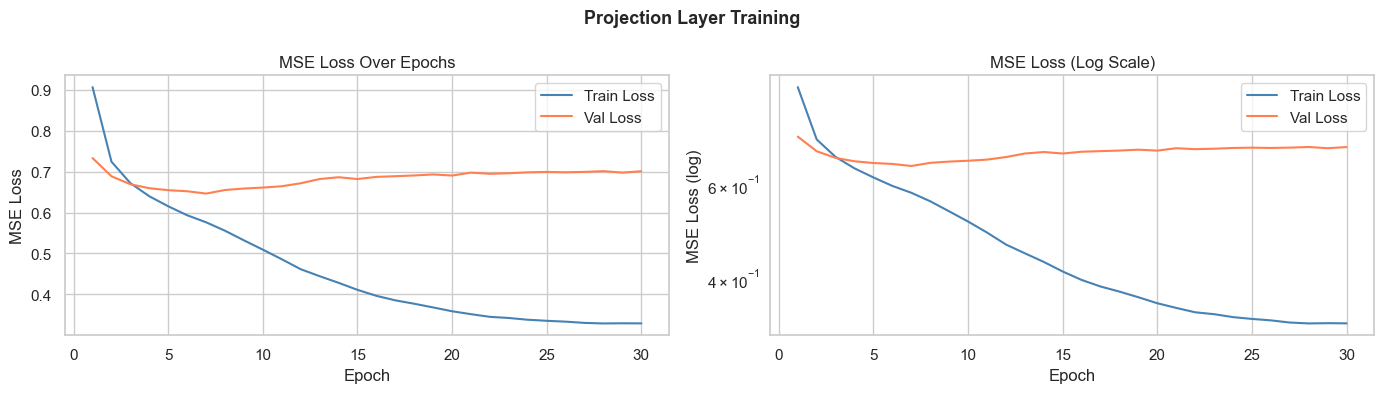

Final train loss : 0.329063
Final val loss   : 0.701083
Overfit ratio    : 2.13  (val/train, < 2.0 is acceptable)
  ✅ Overfitting is within acceptable range.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Projection Layer Training', fontsize=13, fontweight='bold')

epochs_range = range(1, PROJ_EPOCHS + 1)
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('MSE Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, val_losses,   label='Val Loss',   color='coral')
axes[1].set_yscale('log')
axes[1].set_title('MSE Loss (Log Scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log)')
axes[1].legend()

plt.tight_layout()
plt.savefig('./outputs/projector_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag potential overfitting
overfit_ratio = val_losses[-1] / train_losses[-1]
print(f'Final train loss : {train_losses[-1]:.6f}')
print(f'Final val loss   : {val_losses[-1]:.6f}')
print(f'Overfit ratio    : {overfit_ratio:.2f}  (val/train, < 2.0 is acceptable)')
if overfit_ratio > 2.5:
    print('  ⚠️  Possible overfitting. Consider increasing Dropout or reducing PROJ_EPOCHS.')
else:
    print('  ✅ Overfitting is within acceptable range.')

---
## 🔊 CELL 7 — Load HiFi-GAN Vocoder

In [17]:
from speechbrain.inference.vocoders import HIFIGAN
from speechbrain.utils.fetching import LocalStrategy

hifigan = HIFIGAN.from_hparams(
    source='speechbrain/tts-hifigan-ljspeech',
    savedir='./pretrained_models/hifigan',
    local_strategy=LocalStrategy.COPY
)
hifigan = hifigan.to('cpu')  # Keep on CPU as fixed earlier
print('✅ HiFi-GAN loaded successfully.')

if torch.cuda.is_available():
    print(f'   VRAM after HiFi-GAN load: {torch.cuda.memory_allocated()/1e9:.2f} GB')

hifigan = hifigan.to('cpu')

def mel_to_wav(mel_flat, projector_mel_scaler, n_mels, target_frames):
    mel_flat_denorm = projector_mel_scaler.inverse_transform(mel_flat.reshape(1, -1))[0]
    mel_2d = mel_flat_denorm.reshape(n_mels, target_frames).astype(np.float32)
    
    # Normalize
    mel_2d = mel_2d - mel_2d.max()
    mel_2d = np.clip(mel_2d, -80.0, 0.0)
    
    # dB → power
    mel_power = librosa.db_to_power(mel_2d)
    
    # Griffin-Lim inversion — no neural network needed
    wav = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_iter=64        # More iterations = better quality, slower
    )
    
    # Normalize
    wav = wav / (np.abs(wav).max() + 1e-8)
    return wav

✅ HiFi-GAN loaded successfully.
   VRAM after HiFi-GAN load: 0.24 GB


c:\Users\Garv Sharma\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [16]:
# Check if real mels have temporal variation or are also flat
real_wav, _ = librosa.load(file_index.iloc[0]['path'], sr=TARGET_SR)
real_mel = librosa.feature.melspectrogram(y=real_wav, sr=TARGET_SR, n_mels=N_MELS)
real_mel_db = librosa.power_to_db(real_mel, ref=np.max)

# Check frame-to-frame variation
frame_std = real_mel_db.std(axis=1).mean()  # avg std across mel bins over time
print(f'Real mel temporal std    : {frame_std:.4f}')

mel_pred_denorm = mel_scaler.inverse_transform(mel_pred_sc.reshape(1,-1))[0]
mel_2d = mel_pred_denorm.reshape(N_MELS, TARGET_FRAMES)
pred_frame_std = mel_2d.std(axis=1).mean()
print(f'Predicted mel temporal std: {pred_frame_std:.4f}')
print(f'\nIf predicted std << real std, projector is outputting flat mels.')

Real mel temporal std    : 8.7226
Predicted mel temporal std: 5.8160

If predicted std << real std, projector is outputting flat mels.


---
## 🧪 CELL 8 — EARLY AUDIO SAMPLE CHECK

**Generate and listen to 5 synthetic audio samples BEFORE the full decode run.**

This is the most important checkpoint. If these sound wrong (no resemblance to speech,
pure noise, or completely silent), you should:
- Check your mel normalization
- Try more projection training epochs (PROJ_EPOCHS = 100)
- Check HiFi-GAN input scale expectations

**Do not proceed to Cell 9 if these samples sound unacceptable.**

Found 640 synthetic embedding group files.

       EARLY AUDIO SAMPLE CHECK (5 samples)
Listen to each sample. If output sounds like speech
(even rough/noisy), the pipeline is working.

Sample 1: Actor=1, Emotion=anger, Sentence=1
  Duration : 2.03s  |  RMS: 0.1572  |  Peak: 1.0000
  ✅ Non-silent audio generated. Saved: sample_check_1_actor1_anger.wav


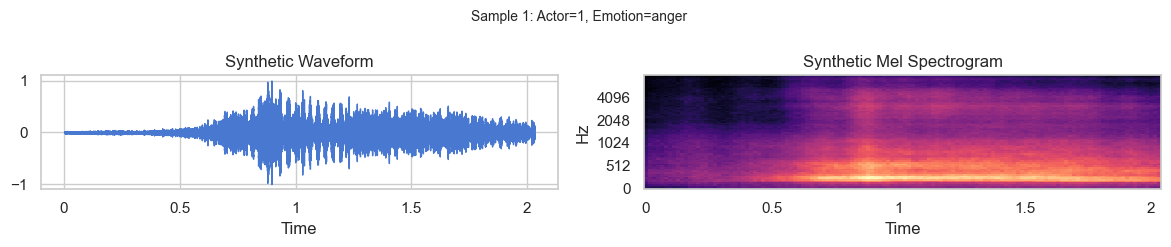


Sample 2: Actor=1, Emotion=anger, Sentence=2
  Duration : 2.03s  |  RMS: 0.1444  |  Peak: 1.0000
  ✅ Non-silent audio generated. Saved: sample_check_2_actor1_anger.wav


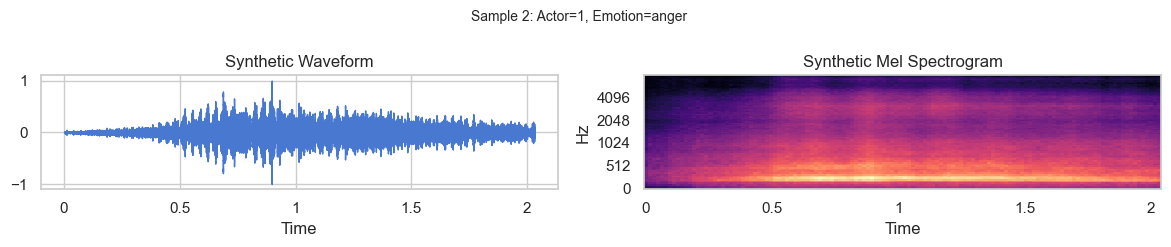


Sample 3: Actor=1, Emotion=anger, Sentence=3
  Duration : 2.03s  |  RMS: 0.1975  |  Peak: 1.0000
  ✅ Non-silent audio generated. Saved: sample_check_3_actor1_anger.wav


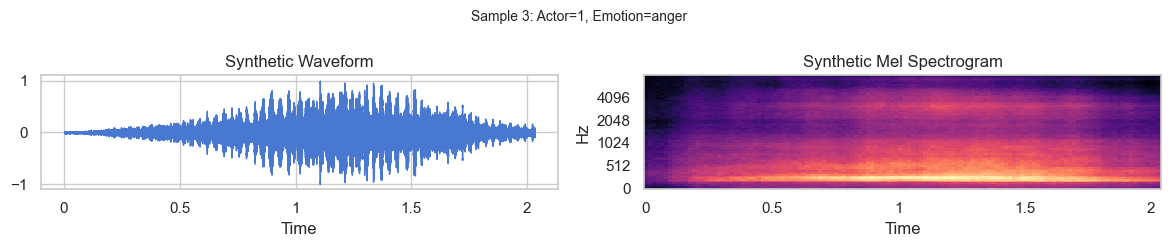


Sample 4: Actor=1, Emotion=anger, Sentence=4
  Duration : 2.03s  |  RMS: 0.1787  |  Peak: 1.0000
  ✅ Non-silent audio generated. Saved: sample_check_4_actor1_anger.wav


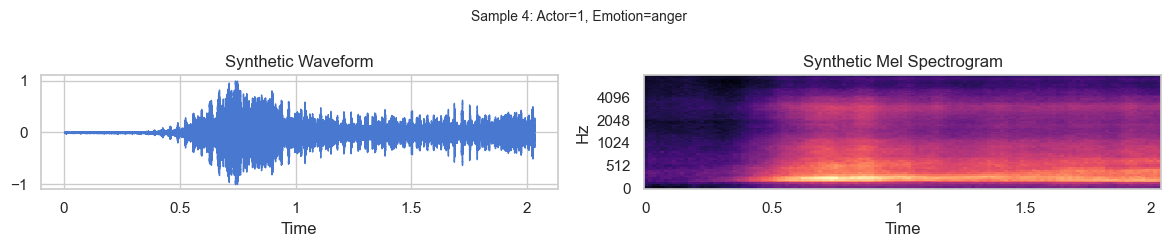


Sample 5: Actor=1, Emotion=anger, Sentence=5
  Duration : 2.03s  |  RMS: 0.1467  |  Peak: 1.0000
  ✅ Non-silent audio generated. Saved: sample_check_5_actor1_anger.wav


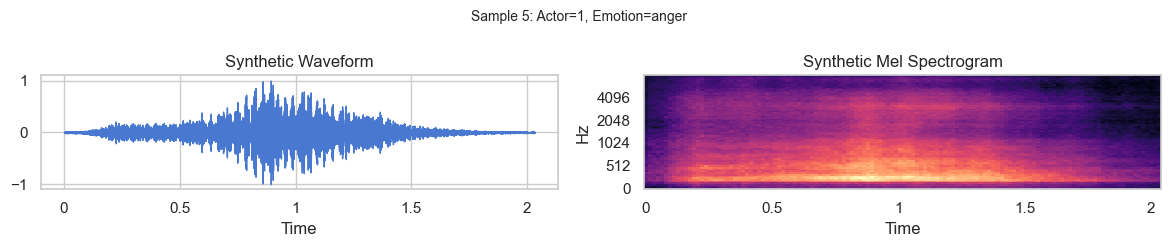


✅ EARLY AUDIO CHECK PASSED — Proceed to full decode (Cell 9).


In [18]:
import re

synth_emb_files = list(SYNTH_EMB_DIR.glob('synth_actor*_sent*_*.npy'))
print(f'Found {len(synth_emb_files)} synthetic embedding group files.')

# Pick 5 diverse test groups (different actors + emotions)
test_groups = synth_emb_files[:5]  # First 5 alphabetically

print('\n' + '='*55)
print('       EARLY AUDIO SAMPLE CHECK (5 samples)')
print('='*55)
print('Listen to each sample. If output sounds like speech')
print('(even rough/noisy), the pipeline is working.\n')

sample_check_results = []

for i, fpath in enumerate(test_groups):
    match = re.match(r'synth_actor(\d+)_sent(\d+)_(.+)\.npy', fpath.name)
    actor, sentence, emotion = int(match.group(1)), int(match.group(2)), match.group(3)

    synth_embs = np.load(fpath)   # (35, 1536)
    # Project first synthetic embedding to mel space
    emb_input = emb_scaler.transform(synth_embs[[0]]).astype(np.float32)
    emb_tensor = torch.tensor(emb_input).to(device)

    with torch.no_grad():
        mel_pred = projector(emb_tensor).cpu().numpy()[0]  # (MEL_DIM,)

    wav = mel_to_wav(mel_pred, mel_scaler, N_MELS, TARGET_FRAMES)

    # Save the sample
    sample_path = OUTPUTS_DIR / f'sample_check_{i+1}_actor{actor}_{emotion}.wav'
    sf.write(str(sample_path), wav, TARGET_SR)

    # Metrics
    rms    = np.sqrt(np.mean(wav**2))
    peak   = np.abs(wav).max()
    silent = rms < 0.001

    print(f'Sample {i+1}: Actor={actor}, Emotion={emotion}, Sentence={sentence}')
    print(f'  Duration : {len(wav)/TARGET_SR:.2f}s  |  RMS: {rms:.4f}  |  Peak: {peak:.4f}')
    if silent:
        print('  ❌ WARNING: Near-silent output. Check mel normalization.')
    else:
        print(f'  ✅ Non-silent audio generated. Saved: {sample_path.name}')

    sample_check_results.append({'actor': actor, 'emotion': emotion,
                                   'rms': rms, 'peak': peak, 'silent': silent})

    # Display waveform
    fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
    fig.suptitle(f'Sample {i+1}: Actor={actor}, Emotion={emotion}', fontsize=10)
    librosa.display.waveshow(wav, sr=TARGET_SR, ax=axes[0])
    axes[0].set_title('Synthetic Waveform')
    mel_2d = mel_scaler.inverse_transform(mel_pred.reshape(1,-1))[0].reshape(N_MELS, TARGET_FRAMES)
    librosa.display.specshow(mel_2d, sr=TARGET_SR, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', fmax=FMAX,
                              ax=axes[1], cmap='magma')
    axes[1].set_title('Synthetic Mel Spectrogram')
    plt.tight_layout(); plt.show()

    # Play inline
    ipd.display(ipd.Audio(wav, rate=TARGET_SR))
    print()

# --- Overall verdict ---
n_silent = sum(r['silent'] for r in sample_check_results)
print('='*55)
if n_silent == 0:
    print('✅ EARLY AUDIO CHECK PASSED — Proceed to full decode (Cell 9).')
elif n_silent < 3:
    print(f'⚠️  {n_silent}/5 samples are silent. Check mel normalization before proceeding.')
else:
    print(f'❌ EARLY AUDIO CHECK FAILED — {n_silent}/5 silent.')
    print('   Do NOT run Cell 9. Debug projector training or mel normalization.')
print('='*55)

---
## 🚀 CELL 9 — Full Synthetic Audio Generation

⚠️ **Only run this if Cell 8 passed.** ⚠️

Decodes all synthetic embeddings to `.wav` files.
Expected time with GPU: **30–90 minutes** depending on GPU speed and group count.
Output saved in same structure as real dataset (`synthetic_audio/{actor}/sessionSYNTH/{emotion}/`).

In [ ]:
decode_log = []
decode_errors = []
t_start = time.time()

print(f'Starting full audio generation...')
print(f'Total groups: {len(synth_emb_files)}')
print(f'Per group   : 35 synthetic samples → {len(synth_emb_files) * 35} total WAV files')
print()

for fpath in tqdm(synth_emb_files, desc='Decoding groups'):
    match = re.match(r'synth_actor(\d+)_sent(\d+)_(.+)\.npy', fpath.name)
    if not match:
        continue
    actor    = int(match.group(1))
    sentence = int(match.group(2))
    emotion  = match.group(3)

    synth_embs = np.load(fpath)   # (35, 1536)

    # Create output directory
    out_dir = SYNTH_AUDIO_DIR / str(actor) / 'sessionSYNTH' / emotion
    out_dir.mkdir(parents=True, exist_ok=True)

    group_rms_list = []

    for j, emb in enumerate(synth_embs):
        try:
            emb_sc = emb_scaler.transform(emb.reshape(1, -1)).astype(np.float32)
            emb_t  = torch.tensor(emb_sc).to(device)
            with torch.no_grad():
                mel_pred = projector(emb_t).cpu().numpy()[0]
            wav = mel_to_wav(mel_pred, mel_scaler, N_MELS, TARGET_FRAMES)

            fname = f'{actor}.SYNTH.{emotion}-{sentence:02d}-{j+1:03d}.wav'
            sf.write(str(out_dir / fname), wav, TARGET_SR)

            rms = np.sqrt(np.mean(wav**2))
            group_rms_list.append(rms)

        except Exception as e:
            decode_errors.append({
                'actor': actor, 'sentence': sentence,
                'emotion': emotion, 'idx': j, 'error': str(e)
            })

    decode_log.append({
        'actor': actor, 'sentence': sentence, 'emotion': emotion,
        'mean_rms': np.mean(group_rms_list) if group_rms_list else 0,
        'n_decoded': len(group_rms_list),
        'n_failed' : len(synth_embs) - len(group_rms_list),
    })

    # Periodic VRAM report
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

decode_df = pd.DataFrame(decode_log)
decode_df.to_csv('./outputs/decode_log.csv', index=False)

t_elapsed = time.time() - t_start
print(f'\n✅ Full decode complete!')
print(f'   Files generated : {decode_df["n_decoded"].sum()}')
print(f'   Errors          : {len(decode_errors)}')
print(f'   Time elapsed    : {t_elapsed/60:.1f} minutes')
print(f'   Mean RMS (all)  : {decode_df["mean_rms"].mean():.4f}')

---
## 📊 CELL 10 — Mel Spectrogram Similarity: Real vs Synthetic

Quantitative comparison of real and synthetic mel spectrograms:
- **MSE** (lower = better)
- **Cosine similarity** (higher = better)
- **SSIM-proxy** using per-frame correlation

--- Mel Spectrogram Similarity (Real vs Reconstructed) ---
  Mean MSE         : 206.0288   (lower is better)
  Mean Cosine Sim  : 0.9709  (higher is better, max=1.0)


C:\Users\Garv Sharma\AppData\Local\Temp\ipykernel_9352\3967099541.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=similarity_df, x='emotion', y='cosine_sim', order=emotion_order,
C:\Users\Garv Sharma\AppData\Local\Temp\ipykernel_9352\3967099541.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=similarity_df, x='emotion', y='mse', order=emotion_order,


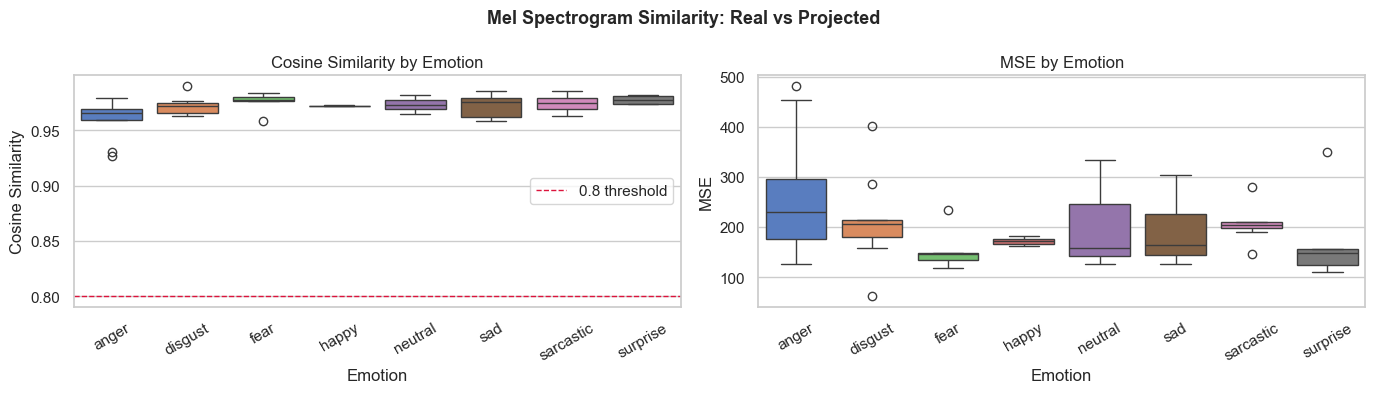

In [11]:
from scipy.spatial.distance import cosine as cosine_dist

# Sample 50 real files and compare to their synthetic counterparts
sample_size = min(50, len(file_index))
sample_rows = file_index.sample(sample_size, random_state=42).reset_index(drop=True)
sample_embs = real_emb_matrix[sample_rows.index]

mse_scores    = []
cosine_scores = []
emotion_tags  = []

projector.eval()
with torch.no_grad():
    for i, (_, row) in enumerate(sample_rows.iterrows()):
        try:
            real_mel = load_mel(row['path'], TARGET_SR, N_MELS, N_FFT,
                                HOP_LENGTH, WIN_LENGTH, FMIN, FMAX, TARGET_FRAMES)
            real_mel_flat = real_mel.flatten()

            emb_sc = emb_scaler.transform(sample_embs[[i]]).astype(np.float32)
            mel_pred_sc = projector(torch.tensor(emb_sc).to(device)).cpu().numpy()[0]
            mel_pred_flat = mel_scaler.inverse_transform(mel_pred_sc.reshape(1,-1))[0]

            mse   = np.mean((real_mel_flat - mel_pred_flat)**2)
            cos   = 1 - cosine_dist(real_mel_flat, mel_pred_flat)
            mse_scores.append(mse)
            cosine_scores.append(cos)
            emotion_tags.append(row['emotion'])
        except:
            pass

similarity_df = pd.DataFrame({'emotion': emotion_tags,
                               'mse': mse_scores,
                               'cosine_sim': cosine_scores})

print('--- Mel Spectrogram Similarity (Real vs Reconstructed) ---')
print(f'  Mean MSE         : {np.mean(mse_scores):.4f}   (lower is better)')
print(f'  Mean Cosine Sim  : {np.mean(cosine_scores):.4f}  (higher is better, max=1.0)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Mel Spectrogram Similarity: Real vs Projected', fontsize=13, fontweight='bold')

emotion_order = sorted(similarity_df['emotion'].unique())
sns.boxplot(data=similarity_df, x='emotion', y='cosine_sim', order=emotion_order,
            palette='muted', ax=axes[0])
axes[0].set_title('Cosine Similarity by Emotion')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Cosine Similarity')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0.8, color='crimson', linestyle='--', linewidth=1, label='0.8 threshold')
axes[0].legend()

sns.boxplot(data=similarity_df, x='emotion', y='mse', order=emotion_order,
            palette='muted', ax=axes[1])
axes[1].set_title('MSE by Emotion')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('./outputs/mel_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 CELL 11 — Emotion Classifier: Train on Real, Test on Synthetic

This is the **key evaluation** for synthetic data quality.  
We train an SVM classifier on **real embeddings** and test it on **synthetic embeddings**.
If the synthetic data has preserved emotion information, the classifier should still
predict the correct emotion from synthetic embeddings.

**Metrics:** Accuracy, Per-class Precision, Recall, F1-Score, Macro F1, Confusion Matrix

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ---- Prepare labels ----
le = LabelEncoder()
le.fit(EMOTIONS)

real_y = le.transform(real_labels_df['emotion'].values)

synth_labels_df  = pd.read_csv(SYNTH_EMB_DIR / 'all_synthetic_labels.csv')
synth_emb_matrix = np.load(SYNTH_EMB_DIR / 'all_synthetic_matrix.npy')
synth_y          = le.transform(synth_labels_df['emotion'].values)

print(f'Real data  : X={real_emb_matrix.shape}, y={real_y.shape}')
print(f'Synth data : X={synth_emb_matrix.shape}, y={synth_y.shape}')

# ---- Train SVM on real data ----
print('\nTraining SVM classifier on real embeddings...')
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',   SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=42))
])

# Cross-validation on real data (baseline)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(clf, real_emb_matrix, real_y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'\n  Cross-val F1 (real data, 5-fold): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

# Final fit on all real data
clf.fit(real_emb_matrix, real_y)
print('  SVM fitted on all real data.')

# ---- Evaluate on synthetic data ----
print('\nEvaluating on synthetic data...')
synth_pred = clf.predict(synth_emb_matrix)

acc       = accuracy_score(synth_y, synth_pred)
prec_mac  = precision_score(synth_y, synth_pred, average='macro', zero_division=0)
rec_mac   = recall_score(synth_y, synth_pred, average='macro', zero_division=0)
f1_mac    = f1_score(synth_y, synth_pred, average='macro', zero_division=0)
f1_weight = f1_score(synth_y, synth_pred, average='weighted', zero_division=0)

print(f'\n  ===== EVALUATION RESULTS =====')
print(f'  Accuracy        : {acc:.4f}   ({acc*100:.1f}%)')
print(f'  Macro Precision : {prec_mac:.4f}')
print(f'  Macro Recall    : {rec_mac:.4f}')
print(f'  Macro F1-Score  : {f1_mac:.4f}')
print(f'  Weighted F1     : {f1_weight:.4f}')
print()

# Per-class report
class_names = le.inverse_transform(sorted(np.unique(synth_y)))
print('  Per-Class Report:')
print(classification_report(synth_y, synth_pred,
                              target_names=class_names, zero_division=0))

# Interpretation guidance
if f1_mac >= 0.7:
    print('  ✅ Macro F1 ≥ 0.7 — Synthetic data has well-preserved emotion content.')
elif f1_mac >= 0.5:
    print('  ⚠️  Macro F1 0.5–0.7 — Moderate quality. Consider reducing ALPHA.')
else:
    print('  ❌ Macro F1 < 0.5 — Poor emotion preservation. '
          'Try lower ALPHA or more projection epochs.')

---
## 📊 CELL 12 — Confusion Matrix

In [ ]:
cm = confusion_matrix(synth_y, synth_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Row-normalize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Emotion Classification: Real SVM → Synthetic Embeddings',
             fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Emotion')
axes[0].set_ylabel('True Emotion')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized — Recall)')
axes[1].set_xlabel('Predicted Emotion')
axes[1].set_ylabel('True Emotion')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/confusion_matrix.png')

---
## 📊 CELL 13 — Per-Class Metrics Bar Chart

In [ ]:
prec_per  = precision_score(synth_y, synth_pred, average=None, zero_division=0)
rec_per   = recall_score(synth_y, synth_pred, average=None, zero_division=0)
f1_per    = f1_score(synth_y, synth_pred, average=None, zero_division=0)

metrics_df = pd.DataFrame({
    'Emotion'  : class_names,
    'Precision': prec_per,
    'Recall'   : rec_per,
    'F1-Score' : f1_per,
})
metrics_df.to_csv('./outputs/per_class_metrics.csv', index=False)

x = np.arange(len(class_names))
width = 0.27

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width, prec_per, width, label='Precision', color='steelblue',   alpha=0.85)
bars2 = ax.bar(x,         rec_per,  width, label='Recall',    color='coral',        alpha=0.85)
bars3 = ax.bar(x + width, f1_per,   width, label='F1-Score',  color='mediumseagreen', alpha=0.85)

ax.set_title('Per-Class Classification Metrics\n(SVM trained on real data, evaluated on synthetic)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Score')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=20)
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='0.7 target')
ax.legend()

# Add macro averages as text
ax.text(0.99, 0.97, f'Macro P: {prec_mac:.3f}\nMacro R: {rec_mac:.3f}\nMacro F1: {f1_mac:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('./outputs/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Metrics saved to outputs/per_class_metrics.csv and per_class_metrics.png')
print()
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

---
## 📊 CELL 14 — Final Pipeline Summary Report

In [ ]:
# Count generated synthetic files
n_synth_wav = len(list(SYNTH_AUDIO_DIR.rglob('*.wav')))

print('=' * 65)
print('            FINAL PIPELINE SUMMARY REPORT')
print('=' * 65)
print(f'  Real audio files        : {len(file_index)}')
print(f'  Synthetic WAV files     : {n_synth_wav}')
print(f'  Dataset inflation       : {(n_synth_wav / len(file_index)):.1f}×')
print()
print('  --- Embedding Quality (Notebook 2) ---')
log_df = pd.read_csv('./outputs/generation_quality_log.csv')
print(f'  Mean cosine sim         : {log_df["mean_cosine"].mean():.4f}')
print(f'  Min cosine sim          : {log_df["mean_cosine"].min():.4f}')
print()
print('  --- Mel Spectrogram Quality (Notebook 3) ---')
print(f'  Projector best val loss : {best_val_loss:.6f}')
print(f'  Mean mel cosine sim     : {np.mean(cosine_scores):.4f}')
print(f'  Mean mel MSE            : {np.mean(mse_scores):.4f}')
print()
print('  --- Emotion Classification Quality ---')
print(f'  Accuracy                : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Macro Precision         : {prec_mac:.4f}')
print(f'  Macro Recall            : {rec_mac:.4f}')
print(f'  Macro F1-Score          : {f1_mac:.4f}')
print(f'  Weighted F1-Score       : {f1_weight:.4f}')
print()
print('  --- Outputs ---')
print(f'  Synthetic audio         : ./synthetic_audio/')
print(f'  Embeddings              : ./synthetic_embeddings/')
print(f'  Plots                   : ./outputs/*.png')
print(f'  Metrics CSV             : ./outputs/per_class_metrics.csv')
print()

# Overall verdict
if f1_mac >= 0.7 and acc >= 0.65:
    verdict = '✅ HIGH QUALITY — Synthetic data is suitable for SER training.'
elif f1_mac >= 0.5:
    verdict = '⚠️  MODERATE — Usable but experiment with ALPHA & more epochs.'
else:
    verdict = '❌ LOW QUALITY — Revisit projector training or embedding quality.'

print(f'  OVERALL VERDICT: {verdict}')
print('=' * 65)